# 01. Master Corpus Data Distribution & Domain Analysis
**Ekegusii-LLM-Translation** -- descriptive statistics over the master sentence and lexical corpora: language coverage, source/provenance distribution, and split sizes.

In [ ]:
# ============================================================
# PATH & REPO AUTO-SYNC BOOSTER — Guarantees latest project code
# ============================================================
import os, sys, site, urllib.request, zipfile

user_site = site.getusersitepackages()
if user_site not in sys.path:
    sys.path.insert(0, user_site)

try:
    cwd = os.getcwd()
except FileNotFoundError:
    cwd = os.path.expanduser('~')
    os.chdir(cwd)

home     = os.path.expanduser('~')
proj_dir = os.path.join(home, 'Ekegusii-LLM-Translation-main')
qwen_cfg = os.path.join(proj_dir, 'configs', 'models', 'qwen_7b.yaml')

# Auto-sync if folder is missing OR outdated (lacks qwen_7b.yaml)
if not os.path.isfile(qwen_cfg):
    print('🔄 Outdated or missing repository detected. Auto-syncing latest code from GitHub...')
    zip_path = os.path.join(home, 'repo.zip')
    urllib.request.urlretrieve('https://github.com/aykahsay/Ekegusii-LLM-Translation/archive/refs/heads/main.zip', zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(home)
    os.remove(zip_path)
    print('✅ Repository auto-synced to latest main commit!')

if os.path.isdir(proj_dir):
    os.chdir(proj_dir)
elif os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

print(f'Working Directory : {os.getcwd()}')
print(f'Python Kernel     : {sys.executable}')


In [2]:
# ============================================================
# ABI CHECK -- numpy/pandas binary compatibility.
# Some Jupyter hosts (e.g. Kineses Cloud conda envs) ship a numpy/pandas
# pair whose compiled C-extension ABI doesn't match, raising
# "numpy.dtype size changed, may indicate binary incompatibility" the
# moment pandas -- and therefore anything importing it, like
# src.master_corpus -- is loaded. Detect and fix it BEFORE any pandas
# import below (see notebooks/00_setup_environment.ipynb for the
# original version of this check).
# ============================================================
import subprocess
import sys


def _abi_ok():
    try:
        import numpy  # noqa: F401
        import pandas  # noqa: F401
        return True
    except ValueError as exc:
        if "binary incompatibility" in str(exc):
            return False
        raise


if not _abi_ok():
    print("numpy/pandas ABI mismatch detected -- attempting fix...")
    fix_a = subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", "numpy>=2.0.0"],
        capture_output=True, text=True,
    )
    if fix_a.returncode != 0:
        print("  numpy upgrade failed (read-only env?) -- downgrading pandas instead...")
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "--quiet", "pandas==2.2.3"],
            capture_output=True, text=True,
        )
    raise RuntimeError(
        "Fixed numpy/pandas ABI mismatch via pip -- you MUST restart the kernel now "
        "(Kernel -> Restart Kernel) and re-run this notebook from the top. The fix "
        "cannot take effect in the current running process."
    )
else:
    print("numpy/pandas ABI OK.")


numpy/pandas ABI OK.


In [3]:
from src.master_corpus.manager import MasterCorpusManager
from src.master_corpus.statistics import CorpusStatistics
from src.utils.constants import SUPPORTED_LANGUAGES

manager = MasterCorpusManager()
stats = CorpusStatistics()

sentence_df = manager.load_sentence_corpus()
lexical_df = manager.load_lexical_corpus()
print(f'Master Sentence Corpus: {len(sentence_df):,} concepts')
print(f'Master Lexical Corpus:  {len(lexical_df):,} entries')

INFO | Loaded Master Sentence Corpus: 49,277 concepts.


INFO | Loaded Master Lexical Corpus: 268 terms.


Master Sentence Corpus: 49,277 concepts
Master Lexical Corpus:  268 entries


## Language coverage & sentence-length statistics

In [4]:
stats.language_statistics(sentence_df, list(SUPPORTED_LANGUAGES))

,non_null_rows,avg_word_count,median_word_count,max_word_count,total_tokens,vocabulary_size,type_token_ratio
language,,,,,,,
English,49277,24.46,21.0,1379,1219444,22228,0.0182
Kiswahili,36110,18.98,17.0,150,685639,51434,0.0750
Ekegusii,47191,20.58,18.0,994,1037606,70446,0.0679


## Source / provenance distribution

In [5]:
stats.source_distribution(sentence_df, 'source')

,count,percentage
source,,
Trilingual-Bible,30971,62.85
ENG-EKE,13167,26.72
PSA,2783,5.65
PSA-English-Kiswahili,2086,4.23
Trilingual-Storybooks,135,0.27
Trilingual-Stories,135,0.27


In [6]:
stats.source_distribution(sentence_df, 'dataset_origin')

,count,percentage
dataset_origin,,
bibile.csv,30971,62.85
English_Ekegusii_Bible.csv,4586,9.31
Web_News_RMS_EgesaFM_English_Ekegusii.csv,4292,8.71
English_Ekegusii_Web_News.csv,4289,8.70
psa.csv,2783,5.65
Scraped_Government_PSAs_Verified.csv,1863,3.78
Ministry_of_Health_Social_Posts.csv,223,0.45
African_Storybooks_Multilingual_Corpus.csv,135,0.27
stories.csv,135,0.27


## Split sizes (fixed 80/10/10 -- see docs/reproducibility.md)

In [7]:
splits = {
    'train': manager.load_train_split(),
    'val': manager.load_val_split(),
    'test': manager.load_test_split(),
}
stats.split_summary(splits)

INFO | Loaded dataset split [master_train.csv]: 39,421 rows.


INFO | Loaded dataset split [master_val.csv]: 4,928 rows.


INFO | Loaded dataset split [master_test.csv]: 4,928 rows.


,rows,percentage
train,39421.0,80.0
val,4928.0,10.0
test,4928.0,10.0


## Visualization

INFO | Saved project status dashboard to outputs/figures/01_corpus_dashboard.png.


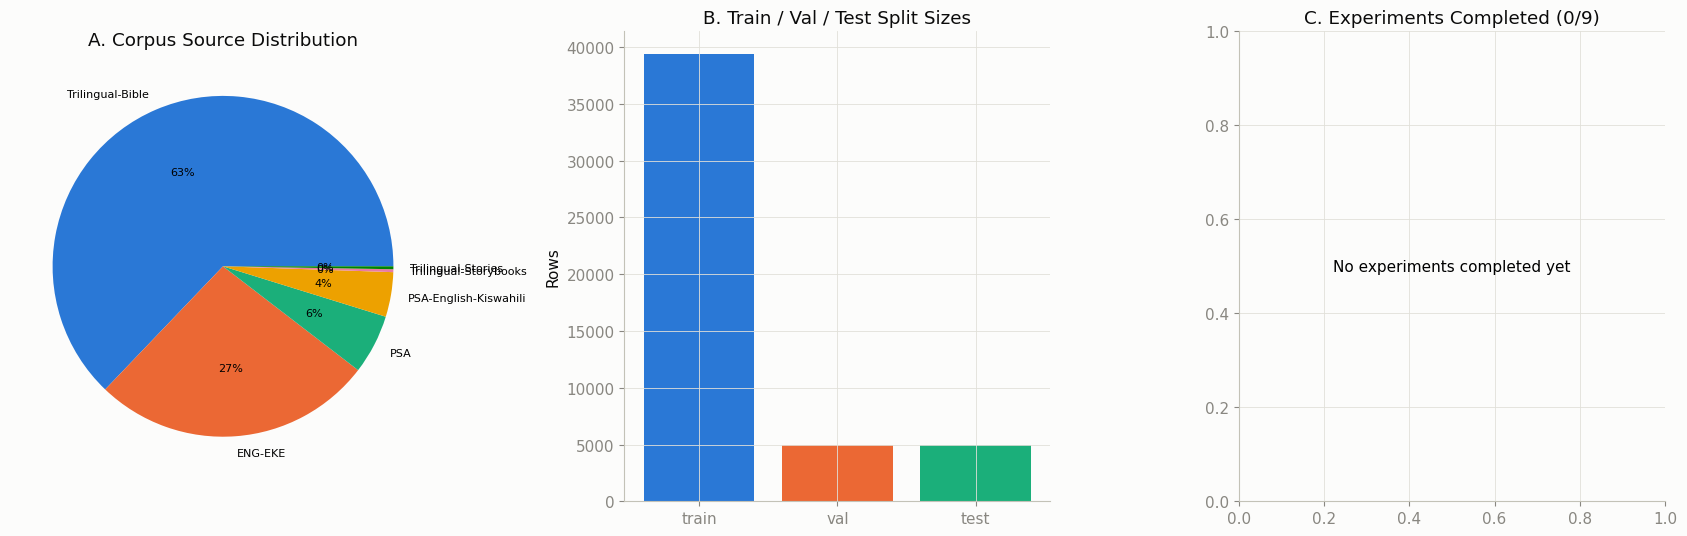

In [8]:
from pathlib import Path
from src.visualization.dashboards import build_project_status_dashboard
import pandas as pd

Path('outputs/figures').mkdir(parents=True, exist_ok=True)
src_dist = stats.source_distribution(sentence_df, 'source')
split_summary = stats.split_summary(splits)
empty_scores = pd.Series(dtype=float)

fig = build_project_status_dashboard(src_dist, split_summary, empty_scores,
    output_path='outputs/figures/01_corpus_dashboard.png')